# Classificação com modelos de Aprendizado de Máquina

## Importação de bibliotecas

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from imblearn.pipeline import Pipeline # pipeline para lidar com dados desbalanceados
from imblearn.under_sampling import RandomUnderSampler


from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (
    f_classif, 
    mutual_info_classif, 
    SelectKBest
)
from sklearn.model_selection import (
    cross_validate, 
    cross_val_predict, 
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.metrics import (
    ConfusionMatrixDisplay, 
    RocCurveDisplay, 
    PrecisionRecallDisplay
)
from sklearn.preprocessing import(
    MinMaxScaler,
    OneHotEncoder,
    PowerTransformer,
    StandardScaler,
)

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, 
    ExtraTreesClassifier, 
    RandomForestClassifier
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier, plot_importance


from src.config import DADOS_CLUSTERED
from src.graficos import visualizar_threshold_metrics

RANDOM_STATE = 42

## Preparação geral

In [2]:
df_clustered = pd.read_parquet(DADOS_CLUSTERED)

In [3]:
# Separação de variáveis

X = df_clustered.drop(columns=["Response"], axis=1)
y = df_clustered['Response']

In [4]:
ohe_cols = [
    "Education",
    "Marital_Status",
    "AgeGroup",
    "HasChildren",
    "HasAcceptedCmp",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Complain",
    "Kidhome",
    "Teenhome",
    "YearsSinceEnrolled",
    "Children",
    "AcceptedTotal",
    'MainCategory'
]

st_cols = [
    "Income",
    "AgeAtEnrollement",
    'Pct_MntWines',
    'Pct_MntMeatProducts'
]

pwt_cols = [
    c for c in X.columns 
    if c.startswith("Mnt") or 
       c.startswith("Num") or 
       (c.startswith("Pct_") and c not in st_cols)
]

minmax_cols = [
    col for col in X.columns if col not in ohe_cols + st_cols + pwt_cols
]

In [5]:
# validação cruzada

st_kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [6]:
preprocessing = ColumnTransformer(
    [
        ("OHE", OneHotEncoder(handle_unknown='ignore'), ohe_cols),
        ("Standart", StandardScaler(), st_cols),
        ("MinMax", MinMaxScaler(feature_range=(-2, 2)), minmax_cols), # importante considerar esse intervalo para que todas escalas estejam iguais
        ("Pwt", PowerTransformer(), pwt_cols)
    ]
)

## Modelos de Classificação

Importante para LGBM e XGB em bases desbalanceadas como a nossa (poucos registros da classe alvo, aqueles que responderam  campanha piloto, comparados aos que recusaram)

In [7]:
scale_pos_weight = np.bincount(y)[0] / np.bincount(y)[1]

Moldeos de classificação escolhidos para teste

In [8]:
models = {

    # Referência

    "DummyClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features,
        "classificador": DummyClassifier(strategy="stratified"),
        'classe' : "Referência"
    },

    # Lineares
    "LogisticRegression": {
        "preprocessor": preprocessing,
        "classificador": LogisticRegression(class_weight="balanced"),
        # n_jobs inútil para classificação binária. 
        ## Na classificação binária, o LogisticRegression precisa treinar apenas um classificador.
        ## A otimização (solver) desse classificador é majoritariamente sequencial. 
        ## O n_jobs não consegue distribuir o cálculo de uma única função de custo por todos os núcleos.
        'classe' : "Linear"

    },

    # Árvore de Decisão

    "DecisionTreeClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features,
        "classificador": DecisionTreeClassifier(random_state=RANDOM_STATE,
                                                class_weight='balanced'),
        'classe' : "Árvore"
    },

    "ExtraTreesClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features,
        "classificador": ExtraTreesClassifier(random_state=RANDOM_STATE,
                                                class_weight='balanced',
                                                n_jobs=-1),
        'classe' : "Árvore"
    },

    "RandomForestClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features,
        "classificador": RandomForestClassifier(random_state=RANDOM_STATE,
                                                class_weight='balanced',
                                                n_jobs=-1),
        'classe' : "Árvore"
        
    },

    # Boosting

    "AdaBoostClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features,
        "classificador": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(class_weight='balanced'),
            algorithm='SAMME', # apenas para manter o código atualizado para as próximas versões
            random_state=RANDOM_STATE
        ),
        'classe' : "Boosting"

    },

    "LGBMClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features,
        "classificador": LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            scale_pos_weight=scale_pos_weight,
        ),
        'classe' : "Boosting"
    },

    "XGBClassifier": {
        "preprocessor": preprocessing, # para evitar erro na pipeline com seleção de features
        "classificador": XGBClassifier(
            random_state=RANDOM_STATE, n_jobs=-1, scale_pos_weight=scale_pos_weight
        ),
        'classe' : "Boosting"
    },


    # Outros
    "KNeighborsClassifier": {
        "preprocessor": preprocessing,
        "classificador": KNeighborsClassifier(),
        'classe' : "Outros"
    },
}

Teste dos modelos e armazenamento dos valores de funções de pontuação (score)

In [9]:
dict_resultados = {}

for modelo, classificador in models.items():

    # criando a pipiline
    pipeline = Pipeline([
        ("preprocessing", classificador['preprocessor']),    
        ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
        (modelo, classificador['classificador'])
    ])

    scores = cross_validate(
        estimator=pipeline, 
        X=X, y=y,
        cv=st_kf,
        scoring=[
            "accuracy",
            "balanced_accuracy",
            "f1",
            "precision",
            "recall",
            "roc_auc",
            "average_precision",
        ],
        n_jobs=-1
    )

    dict_resultados[modelo] = scores


In [10]:
df_resultados = pd.DataFrame(dict_resultados).T.reset_index().rename(columns={'index' : 'model'})

df_resultados = df_resultados.explode(column=df_resultados.columns[1:].to_list()).reset_index(drop=True)
df_resultados["time_seconds"] = df_resultados["fit_time"] + df_resultados["score_time"]

mapeamento_categorias = {modelo: info['classe'] for modelo, info in models.items()}
df_resultados['classe'] = df_resultados['model'].map(mapeamento_categorias)

for c in df_resultados.columns[1:-1]:

    df_resultados[c] = pd.to_numeric(df_resultados[c], errors='coerce')

df_resultados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   model                   45 non-null     object 
 1   fit_time                45 non-null     float64
 2   score_time              45 non-null     float64
 3   test_accuracy           45 non-null     float64
 4   test_balanced_accuracy  45 non-null     float64
 5   test_f1                 45 non-null     float64
 6   test_precision          45 non-null     float64
 7   test_recall             45 non-null     float64
 8   test_roc_auc            45 non-null     float64
 9   test_average_precision  45 non-null     float64
 10  time_seconds            45 non-null     float64
 11  classe                  45 non-null     object 
dtypes: float64(10), object(2)
memory usage: 4.3+ KB


Resultado do teste e ordenação baseado na métrica (score) de preferência para bases desbalanceadas

In [11]:
agrupamento = [
    "model", 
    'classe'
]

df_resultados.groupby(agrupamento).mean().iloc[:, 2:].sort_values(by=["test_average_precision", 'time_seconds'], ascending=[False, True]).style.format("{:.2f}")

,,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,classe,,,,,,,,
LogisticRegression,Linear,0.82,0.81,0.57,0.44,0.81,0.91,0.68,0.11
LGBMClassifier,Boosting,0.76,0.83,0.54,0.38,0.93,0.90,0.66,0.95
XGBClassifier,Boosting,0.76,0.82,0.53,0.37,0.91,0.89,0.63,0.50
RandomForestClassifier,Árvore,0.79,0.80,0.54,0.40,0.81,0.88,0.57,0.27
ExtraTreesClassifier,Árvore,0.80,0.79,0.54,0.41,0.79,0.87,0.55,0.27
AdaBoostClassifier,Boosting,0.74,0.75,0.47,0.34,0.76,0.82,0.46,0.64
KNeighborsClassifier,Outros,0.77,0.75,0.49,0.37,0.71,0.82,0.41,0.25
DecisionTreeClassifier,Árvore,0.73,0.73,0.45,0.32,0.73,0.73,0.28,0.09
DummyClassifier,Referência,0.50,0.50,0.23,0.15,0.50,0.49,0.15,0.09


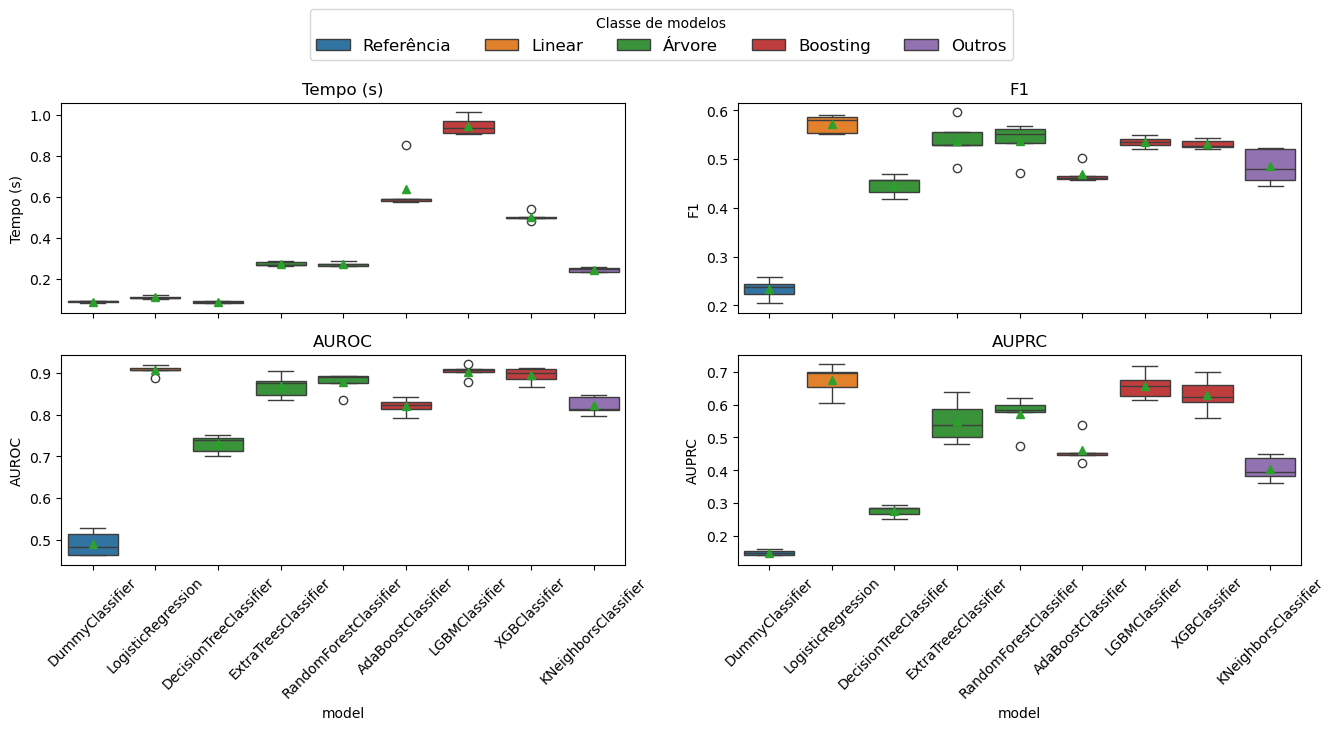

In [12]:
fig, axs = plt.subplots(2, 2, 
                        figsize=(16, 6), 
                        sharex=True)

comparar_metricas = [
        "time_seconds",
        # "test_precision",
        # "test_recall",
        "test_f1",
        "test_roc_auc",
        "test_average_precision",
    ]

nomes_metricas = [
        "Tempo (s)",
        # "Precisão",
        # "Recall",
        "F1",
        "AUROC",
        "AUPRC",
    ]


for ax, metrica, nome in zip(axs.flatten(), comparar_metricas, nomes_metricas):

    b = sns.boxplot(
        data=df_resultados,
        x='model', 
        y=metrica,
        showmeans=True,
        hue="classe",
        ax=ax,

    )

    legend = b.get_legend()
    legend.remove()


    ax.set_title(nome)
    ax.set_ylabel(nome)
    ax.tick_params(axis='x', rotation=45)

labels = [text.get_text() for text in legend.get_texts()]
fig.legend(
    handles=legend.legend_handles, 
    labels=labels, 
    loc='upper center', 
    ncols=5, 
    title='Classe de modelos', 
    bbox_to_anchor=(0.5, 1.05), 
    fontsize=12
)

# plt.subplots_adjust(
#     hspace=0.3,
#     wspace=0.3
# )
plt.show()

**Análise prévia**

Vemos que o `LogisticRegression` performou bem e de forma estável para todas as métricas, inclusive o tempo. Modelos de `Boosting` se beneficiaram de estabilidade na ROC e Average Precison, diferente de modelos de árvore puros; Isso pode destacar o carater mais robusto desse grupo de modelos e talvez um peso maior para interações lineares do que não-lineares. Dessa forma, vamos seguir para com a otimização do modelo vencedor.

## Seleção de features

In [13]:
# Definindo o range de features para testar (ex: de 2 até o máximo disponível)
k_features = range(2, df_clustered.shape[1])
methods = {
    'ANOVA (f_classif)': f_classif,
    'Mutual Info': mutual_info_classif
}

In [14]:
results = {method: [] for method in methods}

for name, func in methods.items():
    for k in k_features:
        
        pipe_test = Pipeline([
            ("preprocessor", preprocessing),
            ("feature_selection", SelectKBest(score_func=func, k=k)),
            ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
            ("LR", LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
        ])
        
        score = cross_val_score(
            pipe_test, 
            X, y, 
            cv=st_kf, 
            scoring='average_precision', 
            n_jobs=-1
        ).mean()
        results[name].append(score)

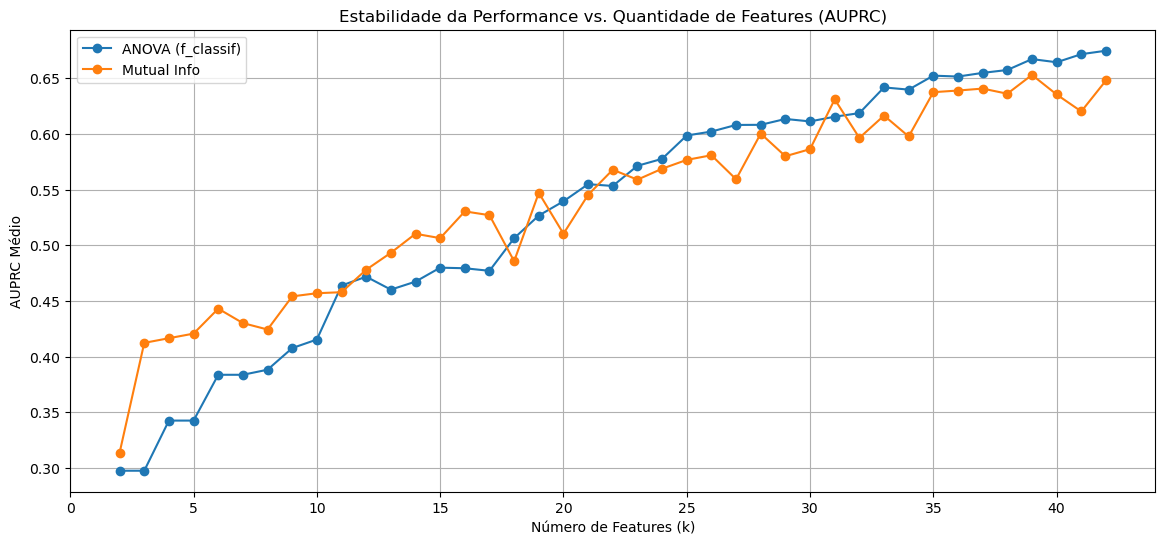

In [15]:
plt.figure(figsize=(14, 6))

for name, scores in results.items():
    plt.plot(k_features, scores, label=name, marker='o')

plt.title('Estabilidade da Performance vs. Quantidade de Features (AUPRC)')
plt.xlabel('Número de Features (k)')
plt.ylabel('AUPRC Médio')
plt.legend()
plt.grid(True)

plt.show()

Como já percebido na análise de PCA, o grande número de _features_ cria uma relação importante para a variância dos dados. Apesar de cada uma individualmente acrescentar pouco no entendimento geral, temos poucas que representam um aumento significativo no ganho de variância e, no caso do gráfico acima, o modelo mais do que dobra de performance na métrica de referência ao considerar todas. Muitas _features_ nessa base significa uma pulverização intensa da variância (informação) e isso fica evidente independentemente do método de escolha para seleção de features.

## Otimização de hiperparâmetros

In [16]:
c_values = np.logspace(-3, 3, 7)

param_grid = [
    # GRUPO 1: Solvers padrão (lbfgs) e liblinear com penalidades L1/L2
    # Nota: lbfgs não aceita L1, então separamos ou usamos apenas L2
    {
        "model__C": c_values,
        "model__solver": ['lbfgs'],
        "model__penalty": ['l2']
    },
    {
        "model__C": c_values,
        "model__solver": ['liblinear'],
        "model__penalty": ['l1', 'l2']
    },

    # GRUPO 2: Solver SAGA com ElasticNet (requer l1_ratio obrigatoriamente)
    {
        "model__C": c_values,
        "model__solver": ['saga'],
        "model__penalty": ['elasticnet'],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    },

    # GRUPO 3: Casos sem penalidade (Penalty=None)
    # Removemos o "model__C" aqui para evitar o UserWarning (C é ignorado sem penalidade)
    {
        "model__solver": ['lbfgs', 'saga'],
        "model__penalty": [None]
    }
]

In [17]:
dict_melhor_modelo = {}

# criando a pipiline
pipeline = Pipeline([
    ('preprocessor', models["LogisticRegression"]['preprocessor']),
    ("rus", RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=1000))
])

refit_metric = 'average_precision'

# Criando o GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    cv=st_kf,
    param_grid=param_grid,
    scoring=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "precision",
        "recall",
        "roc_auc",
        "average_precision",
    ],
    refit=refit_metric,
    n_jobs=-1,
    return_train_score=False,
    verbose=1,
)

grid_search.fit(X, y)

Fitting 5 folds for each of 44 candidates, totalling 220 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('OHE',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Education',
                                                                          'Marital_Status',
                                                                          'AgeGroup',
                                                                          'HasChildren',
                                                                          'HasAcceptedCmp',
                                                                          'AcceptedCmp1',
                                                                          'AcceptedCmp2',
                                                                          'AcceptedCmp3',
                                                                          'AcceptedCmp4',
                                                                          'AcceptedCmp5',
                                                                          'Complain'...
                         {'model__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                          'model__l1_ratio': [0.2, 0.5, 0.8],
                          'model__penalty': ['elasticnet'],
                          'model__solver': ['saga']},
                         {'model__penalty': [None],
                          'model__solver': ['lbfgs', 'saga']}],
             refit='average_precision',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [18]:
dict_grid = pd.DataFrame(grid_search.cv_results_)

df_grid = dict_grid.sort_values(by="rank_test_average_precision")

cols_float = df_grid.select_dtypes(include=['float64', 'float32']).columns
df_grid[cols_float] = df_grid[cols_float].round(2)

df_grid[
    [
        'mean_test_average_precision', 
        'mean_test_f1',
        'mean_test_roc_auc', 
        'rank_test_average_precision'
    ]
].head()

,mean_test_average_precision,mean_test_f1,mean_test_roc_auc,rank_test_average_precision
3,0.68,0.57,0.91,1
30,0.68,0.58,0.91,2
14,0.67,0.57,0.91,3
31,0.67,0.57,0.91,4
32,0.67,0.57,0.90,5


Não houveram grandes melhoras nas métricas de escolha, `mean_test_average_precision` e `mean_test_roc_auc`, como se pode notar. Isso indica certa estabilidade e complexidade para classificação dos dados, uma vez que o modelo vencedor, mesmo com acesso a todas as colunas e os mais variados hiperparâmetros, apresentou ganho negligenciável frente as condições padrão de teste.

In [19]:
df_params = pd.DataFrame(df_grid['params'].tolist(), index=df_grid.index)
df_final = pd.concat([df_grid[['mean_test_average_precision']], df_params], axis=1)

df_final.head()

,mean_test_average_precision,model__C,model__penalty,model__solver,model__l1_ratio
3,0.68,1.0,l2,lbfgs,NaN
30,0.68,1.0,elasticnet,saga,0.2
14,0.67,1.0,l2,liblinear,NaN
31,0.67,1.0,elasticnet,saga,0.5
32,0.67,1.0,elasticnet,saga,0.8


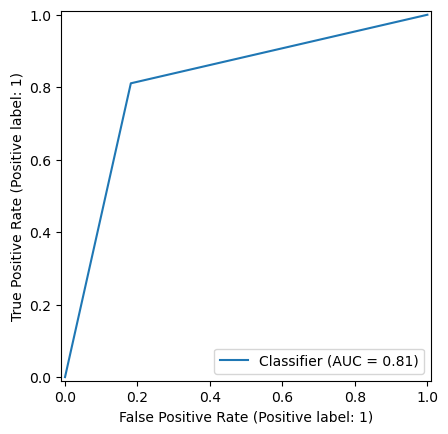

In [20]:
y_pred = cross_val_predict(
    grid_search.best_estimator_,
    X, y,
    cv=st_kf,
    n_jobs=-1
)

roc = RocCurveDisplay.from_predictions(y, y_pred)

A área sob a curva (AUC) de 0.81 indica uma boa capacidade do modelo em distinguir entre as classes. Ele consegue manter uma `Taxa de Verdadeiros Positivos` (**Recall**) alta (~0.80) antes que a `Taxa de Falsos Positivos` comece a subir, um **bom equilíbrio**.

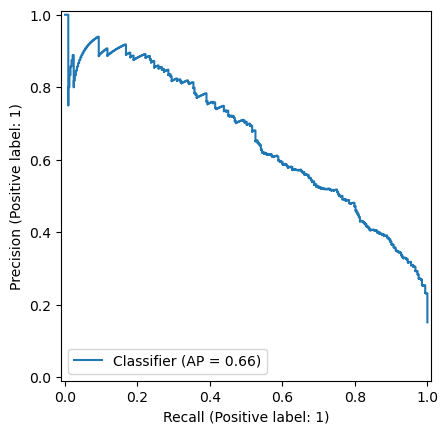

In [21]:
y_pred = cross_val_predict(
    grid_search.best_estimator_,
    X, y,
    cv=st_kf,
    n_jobs=-1,
    method='decision_function',
)

prc = PrecisionRecallDisplay.from_predictions(y, y_pred)

Essa curva é mais rigorosa que a ROC para dados desbalanceados, ela está mostrando como a `precisão` cai à medida que tentamos capturar mais casos positivos (aumentando o `Recall`).

**Consideração dos hiperparâmetros**

**1. C = 1:** Um valor equilibrado para regularização.

**2. L2 (Ridge):** Isso ajuda a "encolher" os coeficientes de variáveis menos importantes, o que explica a estabilidade da curva ROC.

Devemos destacar que o modelo com **elasticnet** e **l1_ratio = 0.2** (modelo 30) teve performance similar. Isso sugere que adicionar um pouco de penalidade L1 (Lasso) não prejudicou o modelo e talvez algumas poucas _features_ sejam irrelevantes. Isso esta de acordo com o pequeno ganho de capacidade preditiva do modelo (variância) com o número de features.

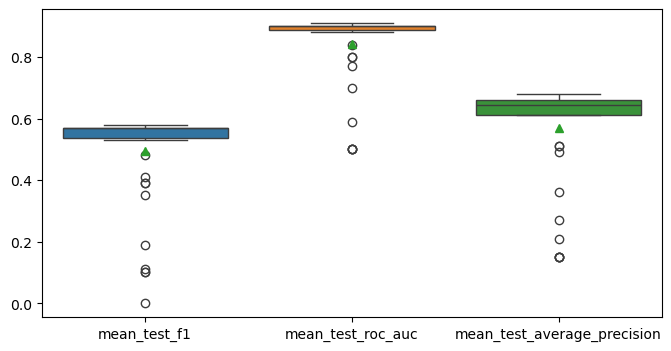

In [22]:
cols_box = [
    'mean_test_f1', 
    'mean_test_roc_auc',
    'mean_test_average_precision'
]

fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(
    data=df_grid[cols_box],
    showmeans=True,
)

plt.show()

## Validação do modelo com melhores parâmetros

In [23]:
# atualizando os parâmetros
pipeline.set_params(**grid_search.best_params_)

scores = cross_validate(
    estimator=pipeline, 
    X=X, y=y,
    cv=st_kf,
    scoring=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "precision",
        "recall",
        "roc_auc",
        "average_precision",
    ],
    n_jobs=-1
)

In [24]:
df_resultados = pd.DataFrame(dict_resultados).T.reset_index().rename(columns={'index' : 'model'})

df_resultados = df_resultados.explode(column=df_resultados.columns[1:].to_list()).reset_index(drop=True)
df_resultados["time_seconds"] = df_resultados["fit_time"] + df_resultados["score_time"]

for c in df_resultados.columns[1:-1]:

    df_resultados[c] = pd.to_numeric(df_resultados[c], errors='coerce')

df_resultados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   model                   45 non-null     object 
 1   fit_time                45 non-null     float64
 2   score_time              45 non-null     float64
 3   test_accuracy           45 non-null     float64
 4   test_balanced_accuracy  45 non-null     float64
 5   test_f1                 45 non-null     float64
 6   test_precision          45 non-null     float64
 7   test_recall             45 non-null     float64
 8   test_roc_auc            45 non-null     float64
 9   test_average_precision  45 non-null     float64
 10  time_seconds            45 non-null     object 
dtypes: float64(9), object(2)
memory usage: 4.0+ KB


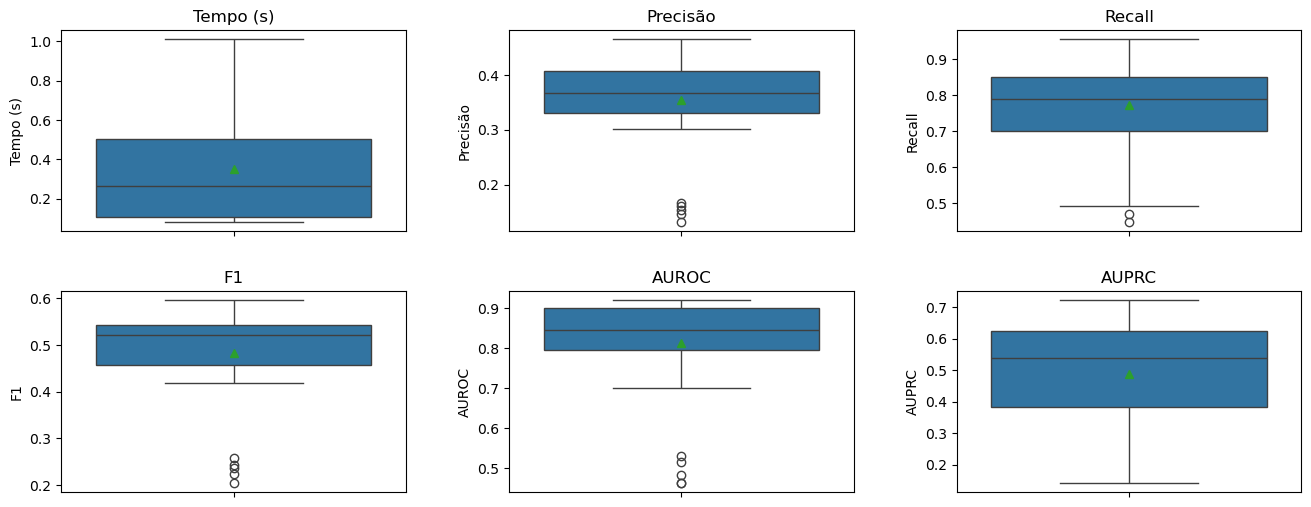

In [25]:
fig, axs = plt.subplots(2, 3, 
                        figsize=(16, 6), 
                        sharex=True)

comparar_metricas = [
        "time_seconds",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_roc_auc",
        "test_average_precision",
    ]

nomes_metricas = [
        "Tempo (s)",
        "Precisão",
        "Recall",
        "F1",
        "AUROC",
        "AUPRC",
    ]


for ax, metrica, nome in zip(axs.flatten(), comparar_metricas, nomes_metricas):

    b = sns.boxplot(
        data=df_resultados,
        y=metrica,
        showmeans=True,
        ax=ax,

    )

    ax.set_title(nome)
    ax.set_ylabel(nome)
    ax.tick_params(axis='x', rotation=45)


plt.subplots_adjust(
    hspace=0.3,
    wspace=0.3
)
plt.show()

## Matriz de confusão

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.2,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE)

In [27]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('OHE',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status', 'AgeGroup',
                                                   'HasChildren',
                                                   'HasAcceptedCmp',
                                                   'AcceptedCmp1',
                                                   'AcceptedCmp2',
                                                   'AcceptedCmp3',
                                                   'AcceptedCmp4',
                                                   'AcceptedCmp5', 'Complain',
                                                   'Kidhome', 'Teenhome',
                                                   'YearsSinceEnrolled',
                                                   'Children', 'AcceptedTotal',
                                                   'MainCategory...
                                                   'MntGoldProds',
                                                   'NumDealsPurchases',
                                                   'NumWebPurchases',
                                                   'NumCatalogPurchases',
                                                   'NumStorePurchases',
                                                   'NumWebVisitsMonth',
                                                   'MntTotal', 'MntRegular',
                                                   'NumTotalPurchases',
                                                   'Pct_MntFruits',
                                                   'Pct_MntFishProducts',
                                                   'Pct_MntSweetProducts',
                                                   'Pct_MntGoldProds'])])),
                ('rus', RandomUnderSampler(random_state=42)),
                ('model',
                 LogisticRegression(C=np.float64(1.0), max_iter=1000))])

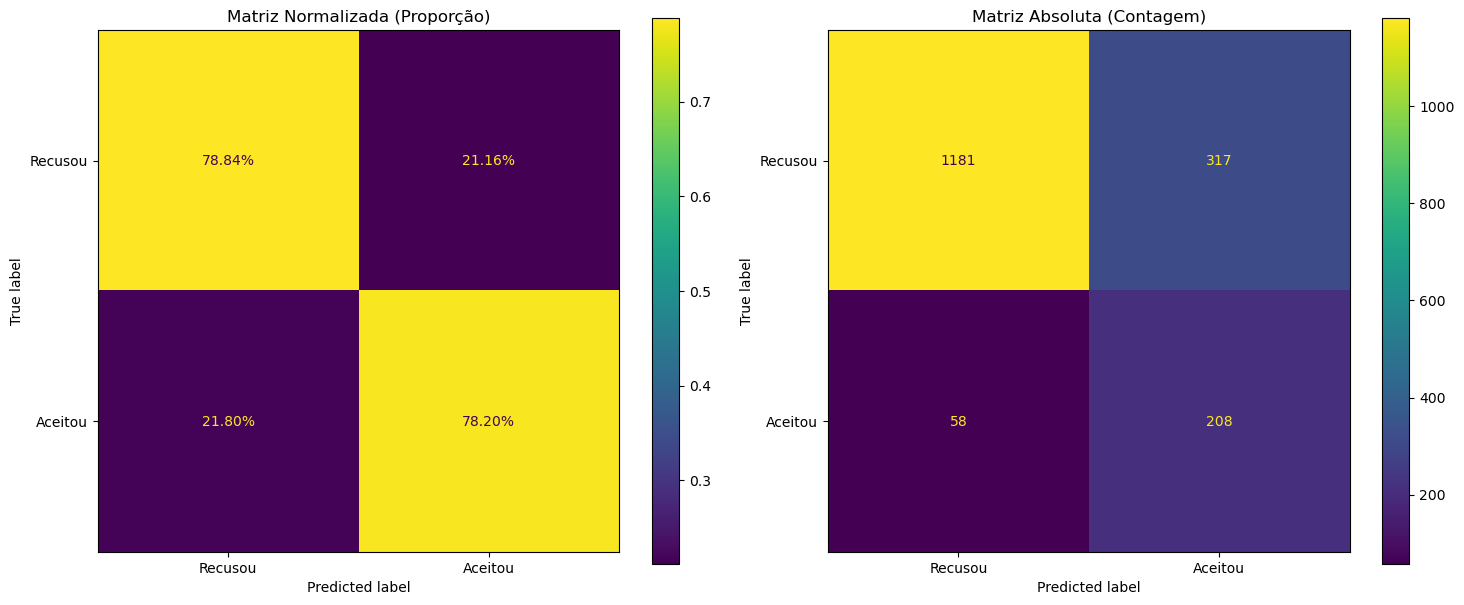

In [28]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 6)) 

normalizes = ["true", None]
titles = ["Matriz Normalizada (Proporção)", "Matriz Absoluta (Contagem)"]

for ax, n, title in zip(axs.flatten(), normalizes, titles):
    
    fmt = ".2%" if n == "true" else "d"
    
    ConfusionMatrixDisplay.from_estimator(
        estimator=pipeline,
        X=X_test,      
        y=y_test,              
        display_labels=["Recusou", "Aceitou"], 
        normalize=n,
        values_format=fmt,
        ax=ax,
    )
    ax.set_title(title)
    ax.grid(False)

plt.tight_layout()
plt.show()

O modelo apresenta uma performance equilibrada entre as classes, acertando a maior parte dos casos de "Recusou" (Verdadeiros Negativos) e "Aceitou" (Verdadeiros Positivos). O desbalanceamento se destaca pela grande proporção de clientes que recusaram (1.181 + 317 = 1.498) em relação aos que aceitaram (58 + 208 = 266).

### visualizar_threshold_metrics

Calcula e plota Verdadeiros Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) e Verdadeiros Positivos (TP) para diferentes limites de decisão (_thresholds_).

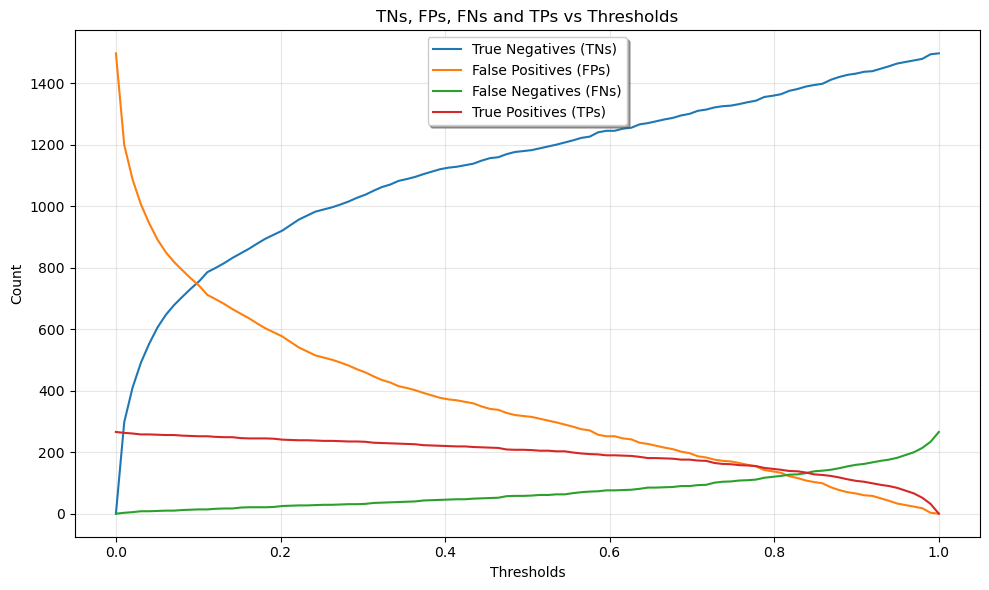

In [32]:
visualizar_threshold_metrics(
    pipeline=pipeline,
    X_test=X_test, y_test=y_test,
)

**Sobre classificação e _threshold_:**

1. **A linha vermelha (TP)** permanece quase plana e alta por grande parte do gráfico. Isso indica que o modelo atribui probabilidades muito altas aos casos de "Aceitou" que ele consegue identificar; ele mantém esses acertos até que o _threshold_ chegue perto de 0.8, valor do gráfico AUC.

2. **A linha verde (FN)** só começa a subir de forma agressiva após o _threshold_ de 0.8. Isso reforça a ideia de que o modelo tem "certeza" sobre os clientes que aceitam, pois eles estão concentrados na faixa de alta probabilidade.

3. Observe que os **FP (laranja)** caem drasticamente conforme aumentamos o _threshold_ até ~0.4. Se para o seu negócio cada "lead inútil" (FP) custa caro, você poderia subir o threshold para 0.7 sem perder quase nenhum TP (vermelho).

**Resumo para _stakeholders_**

Em suma, o _threshold_ (limiar de probabilidade) é a régua que definimos a previsão ser TP, TN,... Logo, quando dizemos que a linha vermelha é estável até 0.7, isso significa que até altas probabilidades o modelo acerta com boa convicção aqueles que aceitariam a campanha. Logo, qualquer _lead_ com 70% de chance, já vale a pena o esforço.  O problema do 0.5 é que, como visto na matriz de confusão, o modelo erra bastante (317 FP, ou seja, pessoas que recusaram, mas que ele disse que aceitariam a campanha). Assim, ao subir a régua para 70%, ou seja, só investir tempo nos que ele classificou com 70% de certeza ou mais, essa taxa cai muito e fica menor que a linha vermelha (TP, aqueles que aceitaram as campanhas e foram classificados corretamente pelo modelo).

Subir o limite para 70% faz com que as ações de _marketing_ foque apenas em quem tem uma probabilidade altíssima de conversão. É a diferença entre gastar tempo e dinheiro para aceionar 500 pessoas e converter 200, ou empregar esforço para 250 pessoas e converter os mesmos 200.

## Avaliando as features (colunas) do modelo

Para isso, vamos fazer um fit para definir o modelo com os parâmetros tunados e com as informações completas da base de dados

In [33]:
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('OHE',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status', 'AgeGroup',
                                                   'HasChildren',
                                                   'HasAcceptedCmp',
                                                   'AcceptedCmp1',
                                                   'AcceptedCmp2',
                                                   'AcceptedCmp3',
                                                   'AcceptedCmp4',
                                                   'AcceptedCmp5', 'Complain',
                                                   'Kidhome', 'Teenhome',
                                                   'YearsSinceEnrolled',
                                                   'Children', 'AcceptedTotal',
                                                   'MainCategory...
                                                   'MntGoldProds',
                                                   'NumDealsPurchases',
                                                   'NumWebPurchases',
                                                   'NumCatalogPurchases',
                                                   'NumStorePurchases',
                                                   'NumWebVisitsMonth',
                                                   'MntTotal', 'MntRegular',
                                                   'NumTotalPurchases',
                                                   'Pct_MntFruits',
                                                   'Pct_MntFishProducts',
                                                   'Pct_MntSweetProducts',
                                                   'Pct_MntGoldProds'])])),
                ('rus', RandomUnderSampler(random_state=42)),
                ('model',
                 LogisticRegression(C=np.float64(1.0), max_iter=1000))])

In [34]:
feat_names = pipeline[:-1].get_feature_names_out() # nomes das features
importance = pipeline['model'].coef_[0] # coeficientes do modelo

df_impor = pd.DataFrame({
    "features" : feat_names,
    "coeficientes" : importance
})


df_impor['coeficientes'] = df_impor['coeficientes'].round(3)

df_impor.sort_values(by='coeficientes', ascending=False).iloc[np.r_[0:5, -5:0]]

,features,coeficientes
4,OHE__Education_PhD,1.400
53,OHE__MainCategory_MntSweetProducts,0.891
5,OHE__Marital_Status_Divorced,0.858
60,MinMax__DaysSinceEnrolled,0.831
70,Pwt__NumCatalogPurchases,0.830
71,Pwt__NumStorePurchases,-0.683
20,OHE__AcceptedCmp1_0,-0.748
59,MinMax__Recency,-0.973
6,OHE__Marital_Status_Has_Partner,-0.982
1,OHE__Education_Basic,-1.386


A importância e o "peso" que o modelo dá para as features durante a seleção das classes. Isso quer dizer que _features_ com valores muito negativos tem grande peso para definir a classe 0, no nosso caso, `Educação Basica` ou `Ter Parceiro`. Enquanto que _features_ muito positiva favorecem a classe 1 (responder a campanha), como ser `PHD` ou gostar de `doces`. **Isso não implica correlação entre dados, apenas o caminho que o modelo encontra para prever as classes.**

Os valores relativamente baixos para Curva ROC e Precison-Recall destacam o tamanho do desafio em prever o comportamento humano. De fato, existem muitas interações complexas e quase nunca se pode afirmar para longe de qualquer contestação que ao fazer algo ou tomar certa direção de decisões o resultado será certo. Devemos sempre manter a cautela de afirmações categóricas e entender que, no final do dia, a decisão é sempre de um ser de vontade própria e que faz julgamentos.

## Conclusão

**Sobre os modelos**

O modelo de escolha baseado nas melhores métricas de avaliação de modelos de classificação foi o `LogisticRegression`. Modelos de gradiente e arvores se mostrarm promissores, em especial os de gradiente com resultados semelhantes nas métricas e tempos otimizados (com é de se esperar para essa classe de modelos). 

Ainda sobre o modelo vencedor, temos um exemplo mais simples que os de Boosting ou Árvore, o que facilita a comunicação com áreas não-técnicas (como steakholders). Ele foi configurado com uma **regularização L2** e parâmetro **C=1**, foi capaz de capturar padrões complexos sem sofrer indícios de sobreajuste (_overfitting_), apresentando uma **Curva ROC de 0.81** que indica uma excelente capacidade de distinção entre as classes. Embora o desafio de prever o comportamento humano seja intrinsecamente complexo, para o modelo características como educação, por exemplo, o **nível de escolaridade** (PHD) e preferências específicas (gostar de doces) são fortes indicadores positivos de conversão; Enquanto fatores como **Educação Básica** estão no oposto tendem a reduzir essa probabilidade. Isso pode ser um indício de que a campanha piloto focou em clientes de premium (geralmente associados a alto nível de escolaridade e renda) e dependentes. 

No entanto, a queda observada na curva de **Precision-Recall (AP = 0.66) reforça a necessidade de cautela ao fazer afirmações categóricas**, lembrando que a decisão final sempre pertence a um indivíduo com vontade própria.


De uma forma geral, como os valores para outros modelos foram semelhantes no primeiro teste, o modelo vencedor se mostrou resistente a melhoria otimização de hiperparâmtros e a base parece distrbuir de forma bem equivalente a variância para todas as features, é indicado ponderar um estudo de otimização de hiperparâmetros, estudo de SHAP Values e Early Stopping com objetivo de comprar esses outros modelos. Isso fugiria do escopodo desse trabalho, mas que já foi demostrado em trabalhos dedicados a classificação em bases desbalancedas, como o [classificação em bases desbalanceadas](https://github.com/Dnlsd/Classificacao_em_bases_desbalanceadas) que pode ser observado pelo link de apoio.

Ainda em tempo, para um estudo de classficação, tivemos resultados satisfatórios e que podem ser úteis em produção para aplicação em avaliação de clientes potenciais, mecanismos de promoção de vendas e carrinhos abandonados, entre outros exemplos.